# autouq on the 64×64 field runs — calibrated UQ against held-out simulation

**Stage 2 of two.** Notebook 09 proved the autouq calibrators on stochastic *toy*
simulators with **closed-form oracles**. Here we validate them on the real target:
the paper's **64×64 CRPS-ensemble ViT** emulators, on three physically distinct
datasets. There is no closed-form oracle now — ground truth is the **held-out
simulation** — so the fourth toy axis (distance to an exact oracle) is replaced by
**truth-referenced dependence diagnostics**.

| dataset | physics | channels | dynamic channel | expected lesson |
|---|---|---|---|---|
| **ad64** | linear advection of vorticity | 1 (vorticity) | vorticity | near-deterministic ⇒ weak-signal calibration demo |
| **gs64** | Gray–Scott reaction–diffusion | 2 (u, v) | u, v | heavy-tailed ⇒ **conformal**; varying mean ⇒ **ECC** |
| **cns64** | compressible Navier–Stokes (smoke) | 3 (smoke, u, v) | smoke | cleanest calibration; ECC on smoke, degenerate on velocity |

**Data hygiene (out-of-sample).** Every number below is computed on data the
forecaster never saw and the calibrator never saw:

- rollouts come from the **held-out test** split (`rollout_test_dataloader`); the
  checkpoint was selected on `valid`, so test touched neither training nor selection;
- each dataset's ~20 test trajectories are split into **10 calibration + 10 OOS**,
  verified **disjoint by trajectory** (zero shared per-trajectory signatures);
- calibrators are **fit on `cal`**, every metric is **evaluated on `oos`**.

**The four axes** (a single coverage number hides too much):

1. **Calibration** — is the stated 90% honest? *coverage vs lead, rank histogram, spread–skill.*
2. **Sharpness** — as tight as possible given calibration? *Winkler / interval score, CRPS.*
3. **Dependence** — is the joint spatial structure right? *energy score + spread–skill of
   the **spatial mean** (sm-SSR): independent per-site calibration collapses it, ECC restores it.*
4. **Truth-referenced fit** — replaces the toys' oracle axis: per-site coverage maps and
   sample fields vs the held-out truth.

**Three calibrators**, matching Stage 1: **EMOS** (parametric, per TIME then per SPACE),
**conformal** `Ensemble(std)` (distribution-free), and **EMOS+ECC** (adds spatial
dependence via ensemble copula coupling).

In [1]:
from pathlib import Path
import numpy as np
import torch
import matplotlib.pyplot as plt

# Compact results artifact (few MB) from dump_field_results.py. For a shared/committed
# notebook, relocate this file into the repo and point RESULTS at the repo-local copy.
RESULTS = Path("/home/ff235/dev/turing/autocast/.autouq_field_stage/field_results.pt")
R = torch.load(RESULTS, map_location="cpu", weights_only=False)

NOMINAL = 0.9
DSETS = ["ad64", "gs64", "cns64"]
STYLE = {"raw": ("o-", "tab:red"), "EMOS": ("s-", "tab:green"), "conformal": ("^-", "tab:blue")}

print("datasets:", list(R.keys()))
for n in DSETS:
    sh = R[n]["spatial"]["shape"]
    print(f"  {n:6s} channels={R[n]['channels']}  oos shape "
          f"(B,T,H,W,C,M)=({sh['B']},{sh['T']},{sh['H']},{sh['W']},{sh['C']},{sh['M']})")

datasets: ['ad64', 'gs64', 'cns64']
  ad64   channels=['vorticity']  oos shape (B,T,H,W,C,M)=(10,100,64,64,1,10)
  gs64   channels=['u', 'v']  oos shape (B,T,H,W,C,M)=(10,100,64,64,2,10)
  cns64  channels=['smoke', 'u', 'v']  oos shape (B,T,H,W,C,M)=(10,100,64,64,3,10)


In [2]:
# ---- panel builders (each draws into a supplied Axes) ----
def ax_cov_lead(ax, temp):
    ax.axhline(NOMINAL, ls="--", c="k", lw=1, zorder=0)
    for k in ("raw", "EMOS", "conformal"):
        mk, c = STYLE[k]
        ax.plot(temp["leads"], temp["cov"][k], mk, ms=3, c=c, label=k)
    ax.set(xlabel="lead", ylabel="coverage", title="① Calibration — coverage vs lead", ylim=(0, 1))
    ax.legend(fontsize=8, loc="lower left")

def ax_wink_lead(ax, temp):
    for k in ("raw", "EMOS", "conformal"):
        mk, c = STYLE[k]
        ax.plot(temp["leads"], temp["wink"][k], mk, ms=3, c=c, label=k)
    ax.set(xlabel="lead", ylabel="Winkler (lower=better)", title="② Sharpness — Winkler vs lead")
    ax.legend(fontsize=8)

def ax_ssr_lead(ax, temp):
    ax.axhline(1.0, ls="--", c="k", lw=1, zorder=0)
    ax.plot(temp["leads"], temp["ssr"]["raw"], "o-", ms=3, c="tab:red", label="raw")
    ax.plot(temp["leads"], temp["ssr"]["EMOS"], "s-", ms=3, c="tab:green", label="EMOS")
    ax.set(xlabel="lead", ylabel="spread / skill", title="① Calibration — spread–skill (→1)", ylim=(0, 1.4))
    ax.legend(fontsize=8)

def ax_rank(ax, temp):
    h = temp["rank_emos"]; h = h / h.sum()
    ax.bar(range(len(h)), h, width=1.0, color="tab:green", alpha=0.8)
    ax.axhline(1 / len(h), ls="--", c="k", lw=1)
    ax.set(xlabel="rank of truth among members", title="① Rank histogram @last lead (EMOS)")

def ax_covmap(ax, sp, channels, method="EMOS", ch=0):
    m = sp["cov_maps"][method][ch]
    im = ax.imshow(m, vmin=0.5, vmax=1.0, cmap="RdYlGn")
    ax.set_title(f"④ Per-site coverage — {method}\n{channels[ch]}: mean {m.mean():.2f}")
    ax.axis("off")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.02)

def ax_smssr(ax, sp, channels):
    x = np.arange(len(channels)); w = 0.26
    for i, (grp, c) in enumerate([("raw", "tab:red"), ("indep", "tab:orange"), ("ecc", "tab:blue")]):
        vals = [sp["spatial_mean_ssr_perchan"][grp][nm] for nm in channels]
        ax.bar(x + (i - 1) * w, vals, w, label=grp, color=c)
    ax.axhline(1.0, ls="--", c="k", lw=1)
    ax.set_yscale("log"); ax.set_xticks(x); ax.set_xticklabels(channels)
    ax.set(ylabel="sm-SSR (log; 1=calib.)", title="③ Dependence — spatial-mean SSR\nindep collapses · ECC restores")
    ax.legend(fontsize=8)

def dashboard(name):
    R_ = R[name]; temp, sp, ch = R_["temporal"], R_["spatial"], R_["channels"]
    fig, ax = plt.subplots(2, 3, figsize=(16, 9))
    ax_cov_lead(ax[0, 0], temp)
    ax_wink_lead(ax[0, 1], temp)
    ax_ssr_lead(ax[0, 2], temp)
    ax_rank(ax[1, 0], temp)
    ax_covmap(ax[1, 1], sp, ch, "EMOS", 0)
    ax_smssr(ax[1, 2], sp, ch)
    fig.suptitle(f"autouq field validation — {name} (64×64 CRPS-ensemble ViT, OOS)", fontsize=14)
    plt.tight_layout(); plt.show()

def coverage_maps(name):
    "per-channel per-site coverage maps, raw -> EMOS -> conformal (green = nominal 0.9)"
    sp, ch = R[name]["spatial"], R[name]["channels"]
    methods = ["raw", "EMOS", "conformal"]
    fig, ax = plt.subplots(len(ch), len(methods), figsize=(3.4 * len(methods), 3.3 * len(ch)),
                           squeeze=False, layout="constrained")
    im = None
    for r, nm in enumerate(ch):
        for c, mth in enumerate(methods):
            m = sp["cov_maps"][mth][r]
            im = ax[r, c].imshow(m, vmin=0.5, vmax=1.0, cmap="RdYlGn")
            ax[r, c].set_xticks([]); ax[r, c].set_yticks([])
            for s in ax[r, c].spines.values(): s.set_visible(False)
            if r == 0: ax[r, c].set_title(mth, fontsize=11)
            if c == 0: ax[r, c].set_ylabel(nm, rotation=0, ha="right", va="center", labelpad=30, fontsize=11)
            ax[r, c].text(0.5, -0.05, f"mean {m.mean():.2f}", transform=ax[r, c].transAxes,
                          ha="center", va="top", fontsize=8)
    fig.colorbar(im, ax=ax, fraction=0.025, pad=0.01, label="per-site coverage (nominal 0.9)")
    fig.suptitle(f"{name} — per-channel per-site coverage maps", fontsize=12)
    plt.show()

def sample_fields(name):
    "truth vs one raw / EMOS-indep / EMOS+ECC member at the last lead, per channel"
    sp, ch = R[name]["spatial"], R[name]["channels"]
    rows = ["truth", "raw", "indep", "ecc"]
    fig, ax = plt.subplots(len(rows), len(ch), figsize=(3.1 * len(ch), 3.0 * len(rows)), squeeze=False)
    for j, nm in enumerate(ch):
        vmin = min(sp["sample_fields"][r][nm].min() for r in rows)
        vmax = max(sp["sample_fields"][r][nm].max() for r in rows)
        for i, r in enumerate(rows):
            a = ax[i, j]
            a.imshow(sp["sample_fields"][r][nm], cmap="viridis", vmin=vmin, vmax=vmax)
            a.set_xticks([]); a.set_yticks([])           # tick-off (not axis-off) so ylabel survives
            for s in a.spines.values(): s.set_visible(False)
            if j == 0: a.set_ylabel(r, rotation=0, ha="right", va="center", labelpad=30, fontsize=11)
            if i == 0: a.set_title(nm, fontsize=11)
    fig.suptitle(f"{name} — sample fields @last lead (rows: truth / raw / EMOS-indep / EMOS+ECC)", fontsize=12)
    plt.tight_layout(); plt.show()

def metrics_table(name):
    "compact scalar summary printed as an aligned text table"
    R_ = R[name]; temp, sp = R_["temporal"], R_["spatial"]
    cm, wm = temp["summary"]["cov_mean"], temp["summary"]["wink_mean"]
    print(f"=== {name} — pointwise calibration (nominal {NOMINAL}) ===")
    print(f"  {'axis':16s}{'raw':>10}{'EMOS':>10}{'conformal':>12}")
    print(f"  {'temporal cov':16s}{cm['raw']:>10.3f}{cm['EMOS']:>10.3f}{cm['conformal']:>12.3f}")
    print(f"  {'temporal Winkler':16s}{wm['raw']:>10.3f}{wm['EMOS']:>10.3f}{wm['conformal']:>12.3f}")
    print(f"  {'per-site cov':16s}{sp['cov_mean']['raw']:>10.3f}{sp['cov_mean']['EMOS']:>10.3f}{sp['cov_mean']['conformal']:>12.3f}")
    print(f"  {'per-site Winkler':16s}{sp['wink']['raw']:>10.3f}{sp['wink']['EMOS']:>10.3f}{sp['wink']['conformal']:>12.3f}")
    print(f"  non-Gaussianity (excess kurtosis @last lead) = {temp['summary']['exkurt_last_lead']:+.2f}")
    print(f"=== {name} — dependence: spatial-mean SSR per channel (1.0 = calibrated) ===")
    print(f"  {'channel':10s}{'raw':>9}{'indep':>9}{'ecc':>9}   verdict")
    smssr = sp["spatial_mean_ssr_perchan"]
    for nm in R_["channels"]:
        rr, ii, ee = smssr['raw'][nm], smssr['indep'][nm], smssr['ecc'][nm]
        # clean ECC win = independent collapses spread below raw, ECC pulls back toward 1
        clean = (ii < 0.75 * rr) and (0.5 <= ee <= 1.6)
        print(f"  {nm:10s}{rr:>9.3f}{ii:>9.3f}{ee:>9.3f}   {'CLEAN ECC win' if clean else 'degenerate (conserved mean)'}")

### How to read each dashboard

Six panels per dataset. **Top row** is the *temporal rollout* (all channels/sites pooled):
① coverage vs lead — raw drifts below the dashed 0.9 as the forecast diverges; EMOS/conformal
restore it. ② Winkler interval score (lower is better; penalises width and misses together).
③ spread–skill ratio toward 1. **Bottom row**: ① rank histogram at the last lead (flat = calibrated);
④ per-site EMOS coverage map (green ≈ 0.9); ③ spatial-mean SSR per channel (log scale) — the
dependence signature: **indep** (orange) collapses the spatial-mean spread, **ECC** (blue) restores
it, but *only where the channel's spatial mean genuinely varies*.

Each dashboard is followed by two supporting figures: the **per-channel per-site coverage maps**
(raw → EMOS → conformal, one row per channel) and **sample fields** (truth vs one calibrated member
from each method at the last lead — a physical-plausibility check).

## ad64 — linear advection (near-deterministic, weak-signal demo)

Single vorticity channel. The ViT nails this near-linear field (ensemble spread ~1e-4), so
there is barely any forecast uncertainty to calibrate — yet the raw ensemble still
**under-covers** (mean temporal coverage ≈ 0.64), and both EMOS and conformal restore it,
with conformal landing on nominal while EMOS slightly *over*-inflates on the spatial axis
(0.97) from the 10-trajectory fit. Dependence is **degenerate** here: vorticity's spatial mean
is conserved (≈ constant), so sm-SSR is a noise/noise ratio and ECC's large value is *not* a win.

In [3]:
metrics_table('ad64')

=== ad64 — pointwise calibration (nominal 0.9) ===
  axis                   raw      EMOS   conformal
  temporal cov         0.641     0.879       0.907
  temporal Winkler     0.001     0.001       0.001
  per-site cov         0.641     0.967       0.907
  per-site Winkler     0.001     0.007       0.001
  non-Gaussianity (excess kurtosis @last lead) = +1.99
=== ad64 — dependence: spatial-mean SSR per channel (1.0 = calibrated) ===
  channel         raw    indep      ecc   verdict
  vorticity     1.020    2.769   22.425   degenerate (conserved mean)


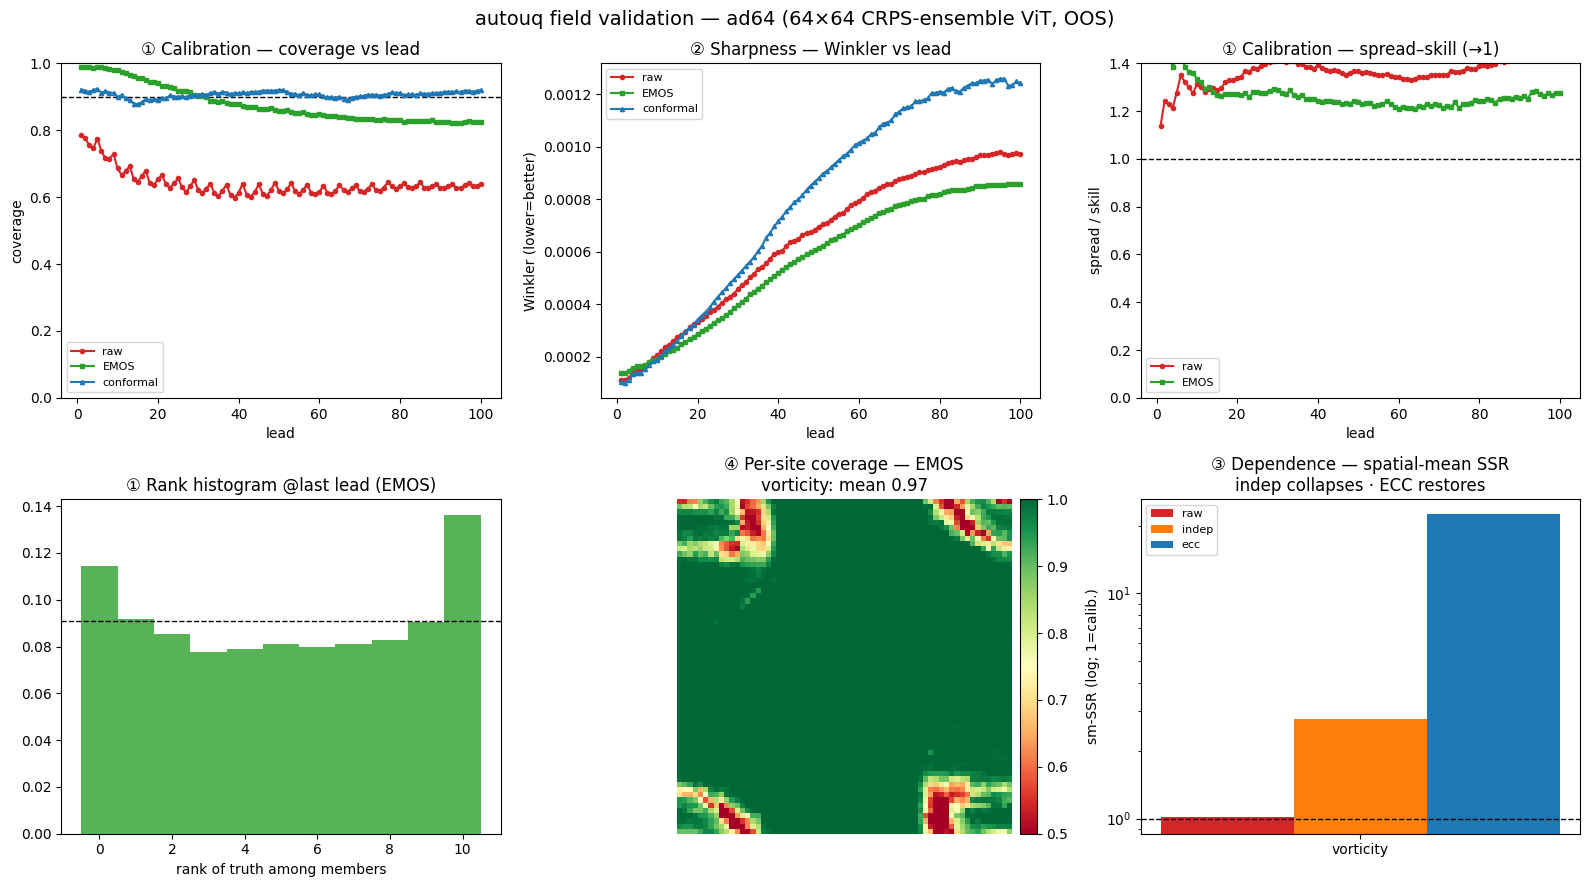

In [4]:
dashboard('ad64')

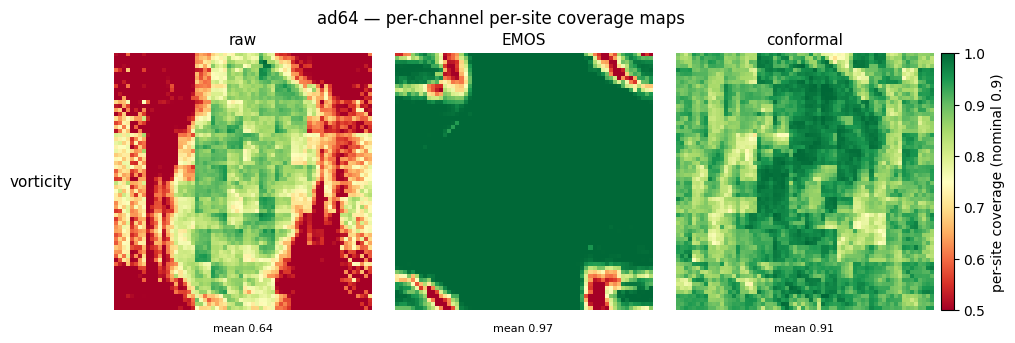

In [5]:
coverage_maps('ad64')

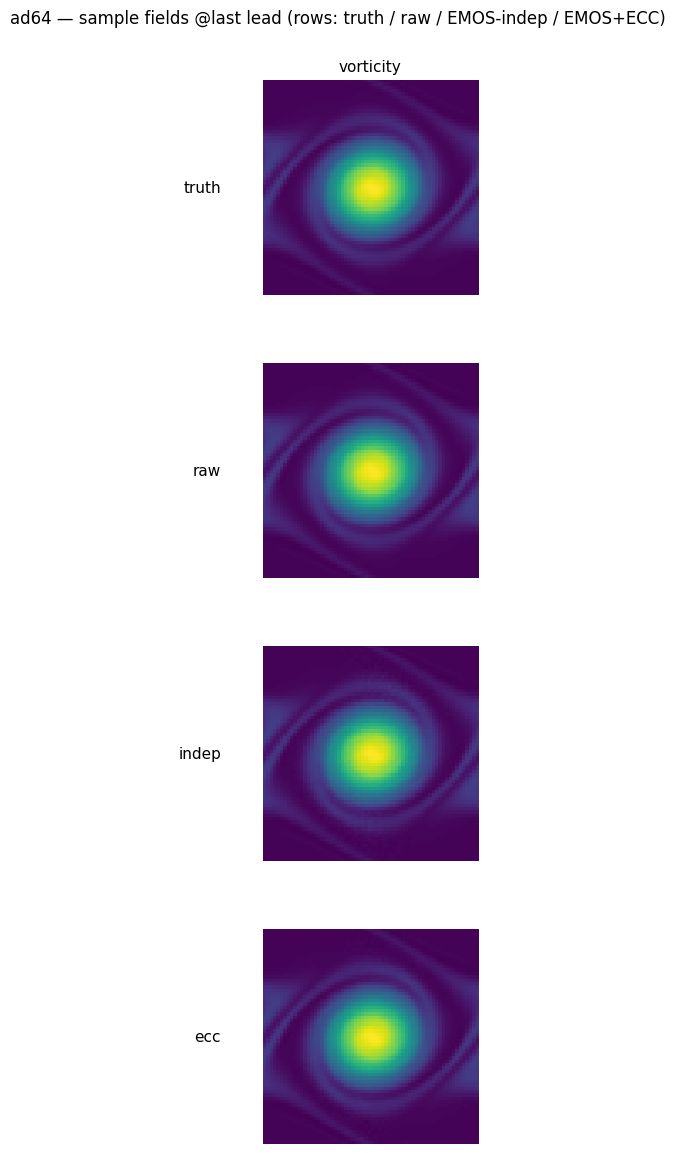

In [6]:
sample_fields('ad64')

## gs64 — Gray–Scott reaction–diffusion (heavy-tailed + genuine spatial-mean variation)

Two channels (u, v). The predictive is strongly **non-Gaussian** (excess kurtosis ≳ +25 at the
last lead), which is exactly where the distribution-free **conformal** method earns its keep:
EMOS's Gaussian tails under-cover (0.83) while conformal reaches nominal (0.94) — at the cost of
wider intervals (higher Winkler). Dependence is the **clean ECC demonstration**: independent
per-site calibration collapses the spatial-mean spread (sm-SSR → 0.03) and **ECC restores it**
(→ 0.76–0.81), because u/v spatial means genuinely vary over the rollout.

In [7]:
metrics_table('gs64')

=== gs64 — pointwise calibration (nominal 0.9) ===
  axis                   raw      EMOS   conformal
  temporal cov         0.456     0.833       0.936
  temporal Winkler     0.022     0.020       0.052
  per-site cov         0.456     0.799       0.936
  per-site Winkler     0.022     0.021       0.052
  non-Gaussianity (excess kurtosis @last lead) = +30.34
=== gs64 — dependence: spatial-mean SSR per channel (1.0 = calibrated) ===
  channel         raw    indep      ecc   verdict
  u             0.825    0.029    0.756   CLEAN ECC win
  v             0.840    0.032    0.810   CLEAN ECC win


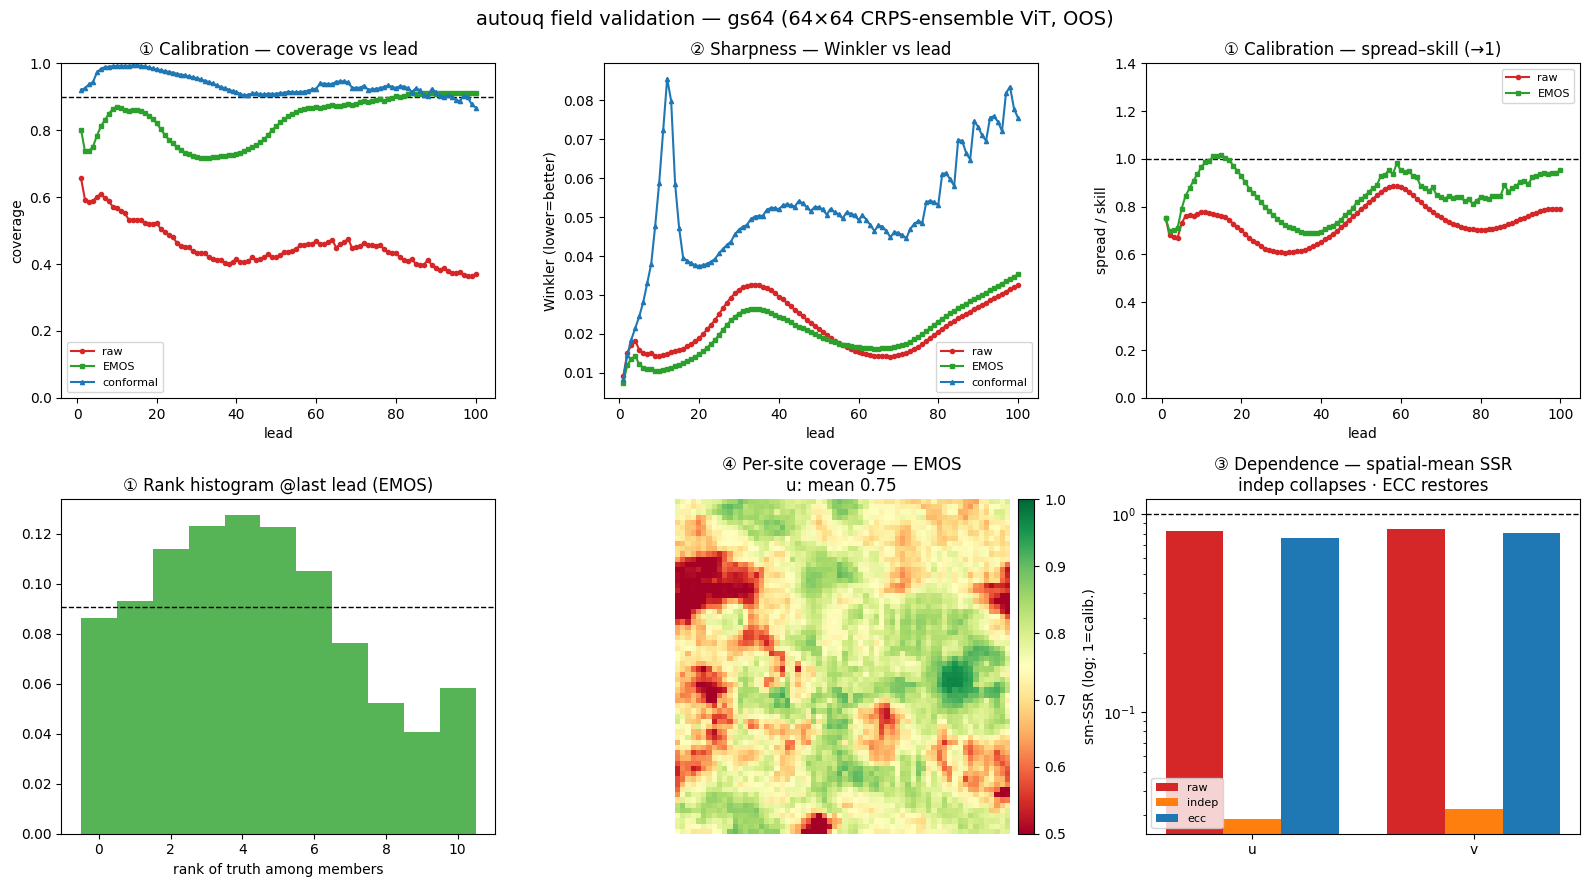

In [8]:
dashboard('gs64')

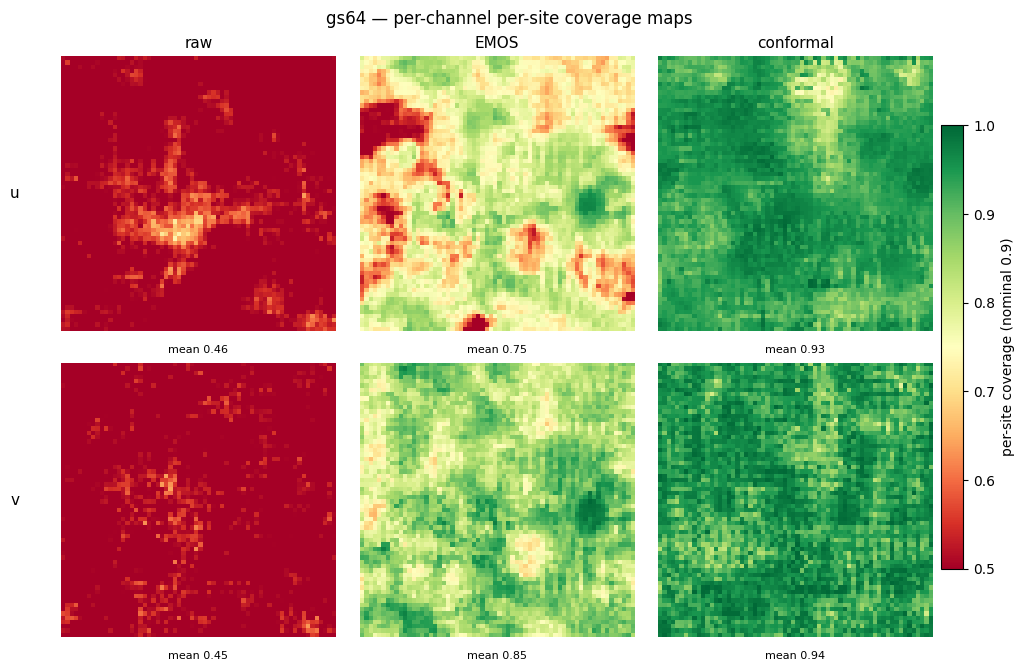

In [9]:
coverage_maps('gs64')

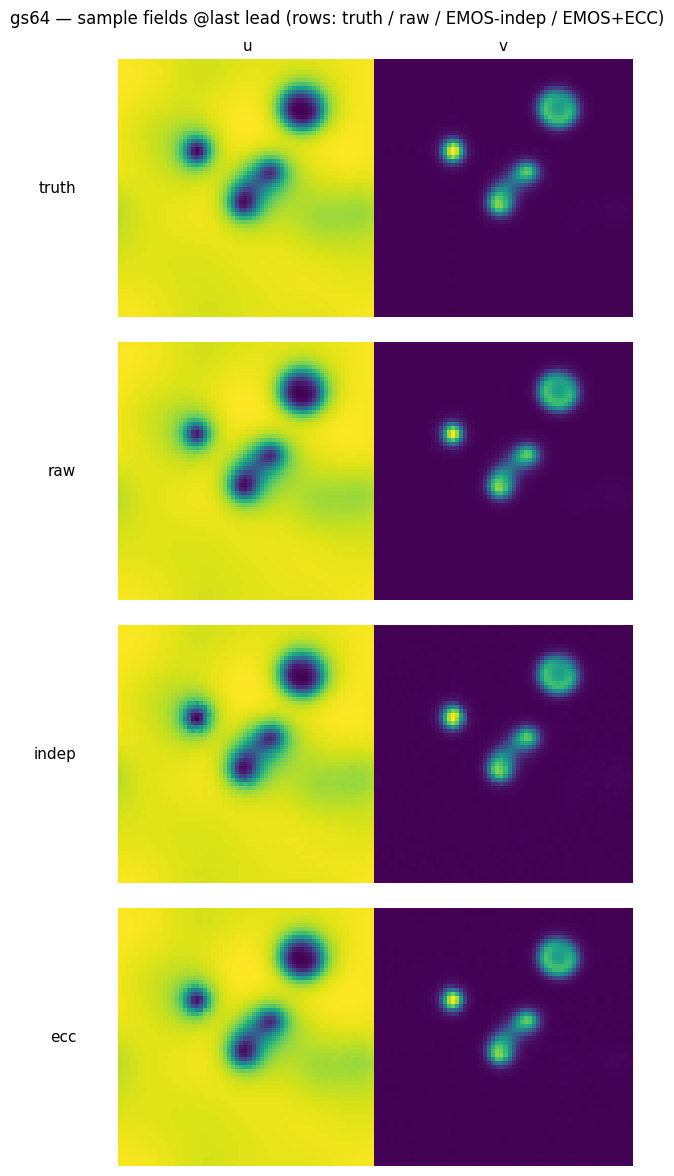

In [10]:
sample_fields('gs64')

## cns64 — compressible Navier–Stokes smoke (cleanest calibration)

Three channels (smoke, u, v). This is the **cleanest pointwise result**: EMOS lands almost
exactly on nominal (temporal 0.898) with the lowest Winkler, because the smoke field is only
mildly non-Gaussian (excess kurtosis ≈ +3). The raw ensemble under-covers most as dynamics
diverge (temporal coverage falls across the rollout). Dependence **splits by channel**: the
**smoke** channel is a clean ECC win (raw 0.67 → indep 0.29 → ECC 1.26), while the
**velocity** channels (u, v) are degenerate — momentum conservation pins their spatial mean near
zero, so sm-SSR is again noise/noise.

In [11]:
metrics_table('cns64')

=== cns64 — pointwise calibration (nominal 0.9) ===
  axis                   raw      EMOS   conformal
  temporal cov         0.577     0.898       0.935
  temporal Winkler     0.132     0.084       0.114
  per-site cov         0.577     0.880       0.935
  per-site Winkler     0.132     0.091       0.114
  non-Gaussianity (excess kurtosis @last lead) = +3.45
=== cns64 — dependence: spatial-mean SSR per channel (1.0 = calibrated) ===
  channel         raw    indep      ecc   verdict
  smoke         0.671    0.290    1.262   CLEAN ECC win
  u             1.281    1.108    1.849   degenerate (conserved mean)
  v             1.570    1.963    3.712   degenerate (conserved mean)


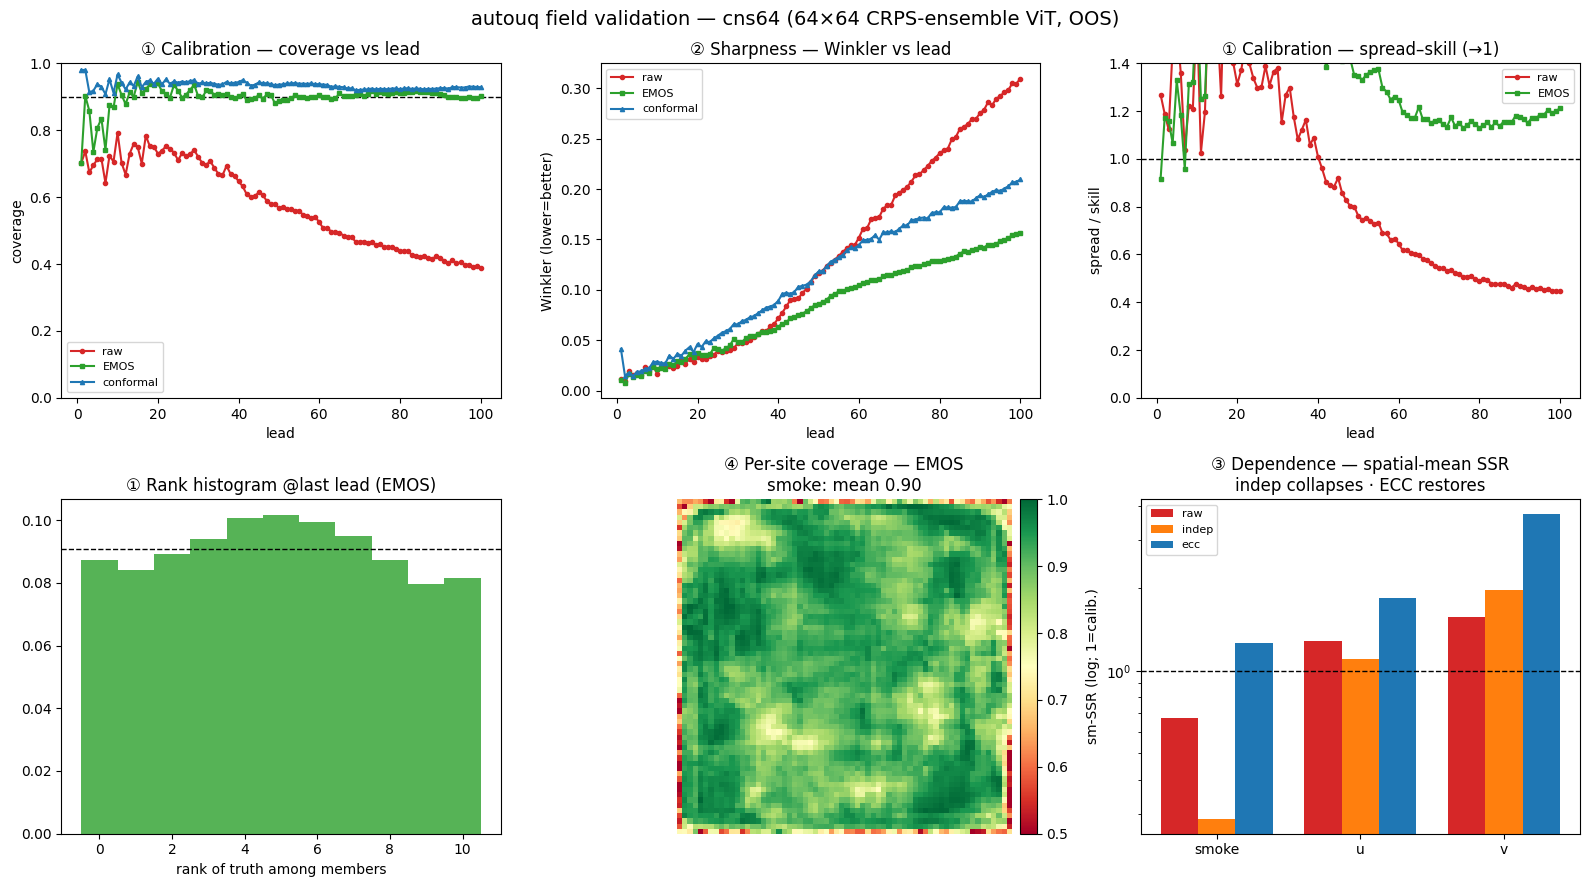

In [12]:
dashboard('cns64')

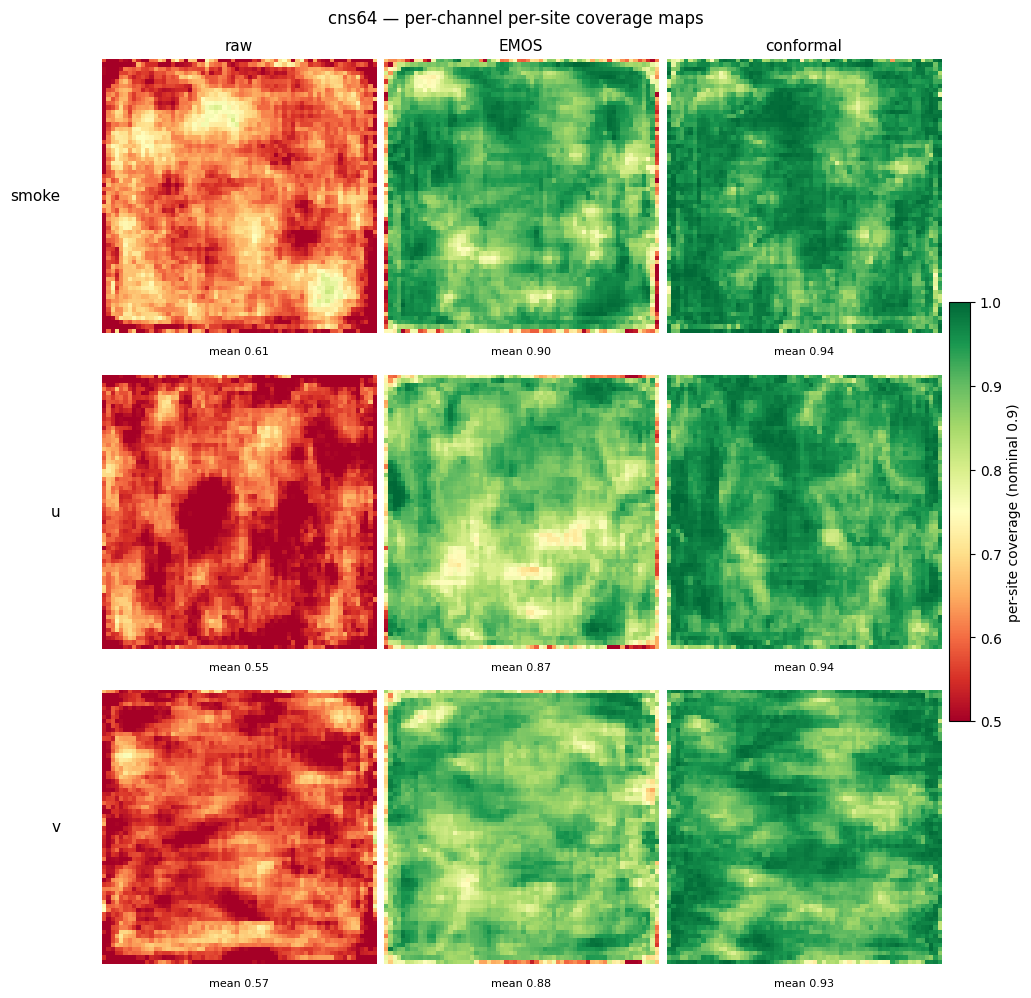

In [13]:
coverage_maps('cns64')

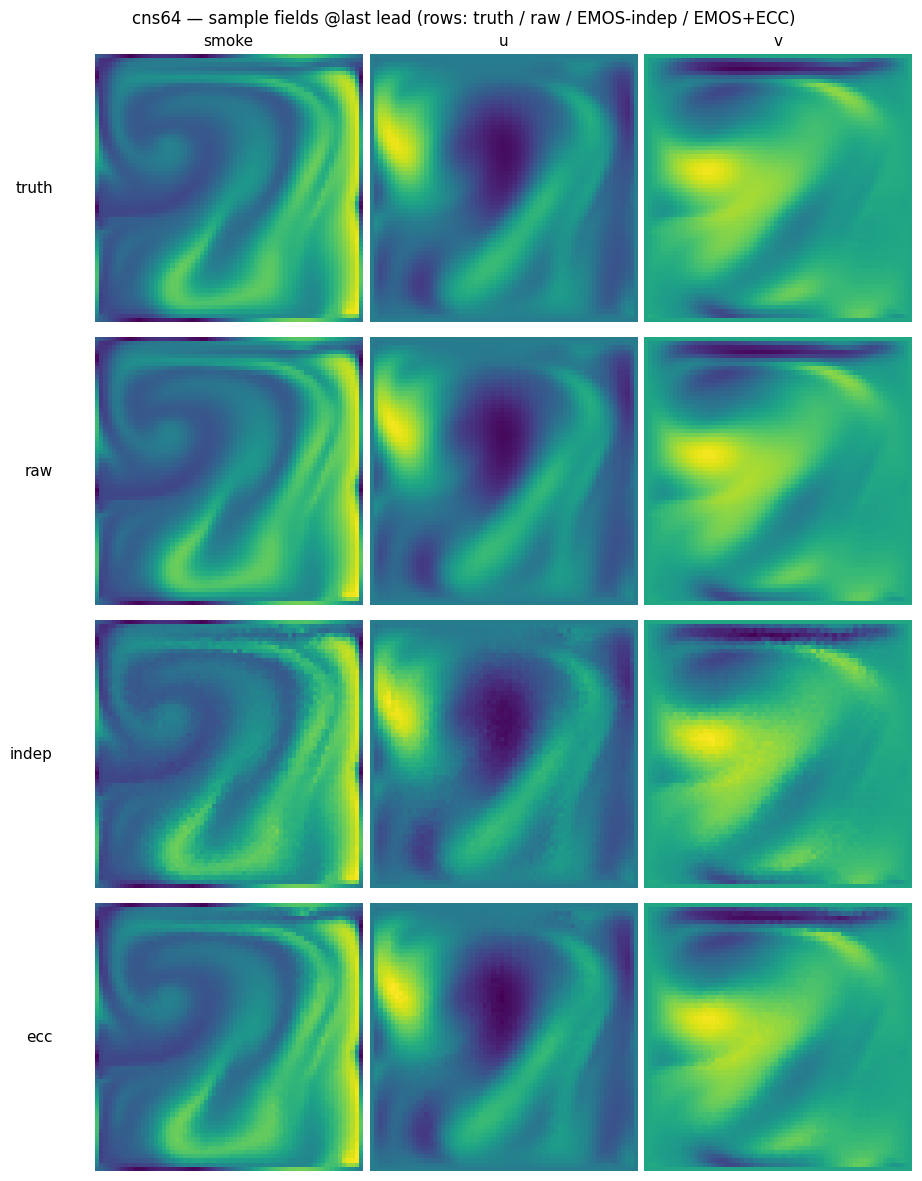

In [14]:
sample_fields('cns64')

## Cross-dataset synthesis — two verified conclusions

Pooling the three datasets (six channels) gives two clean, honest conclusions.

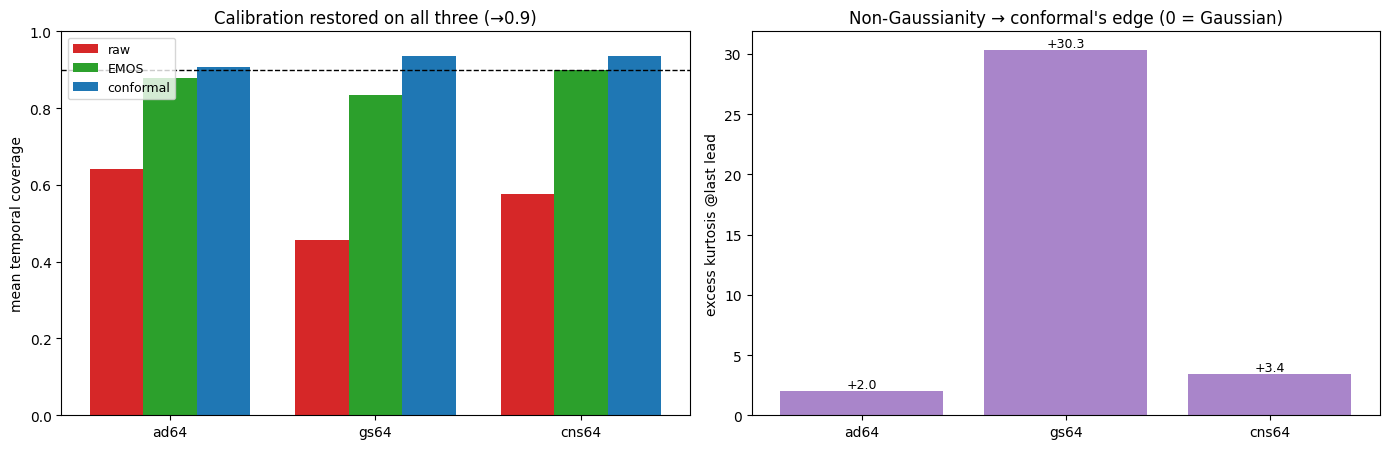

Conclusion 1 — temporal/per-site calibration works everywhere; the raw ensemble under-covers
  and EMOS/conformal restore it. EMOS is sharpest when near-Gaussian (cns64: 0.898 at lowest
  Winkler); conformal is coverage-robust when heavy-tailed (gs64, excess kurtosis ≳ +25) or
  when EMOS over-inflates on the small fit (ad64 spatial) — at the cost of width. Exactly the
  toy prediction (Gaussian ⇒ EMOS, heavy-tailed ⇒ conformal).


In [15]:
# (1) temporal + per-site calibration is restored on ALL three; which method wins tracks non-Gaussianity
fig, ax = plt.subplots(1, 2, figsize=(14, 4.6))
xw = np.arange(len(DSETS))
for i, k in enumerate(("raw", "EMOS", "conformal")):
    ax[0].bar(xw + (i - 1) * 0.26, [R[n]["temporal"]["summary"]["cov_mean"][k] for n in DSETS],
              0.26, label=k, color=STYLE[k][1])
ax[0].axhline(NOMINAL, ls="--", c="k", lw=1)
ax[0].set_xticks(xw); ax[0].set_xticklabels(DSETS)
ax[0].set(ylabel="mean temporal coverage", title="Calibration restored on all three (→0.9)", ylim=(0, 1))
ax[0].legend(fontsize=9)

kurt = [R[n]["temporal"]["summary"]["exkurt_last_lead"] for n in DSETS]
ax[1].bar(xw, kurt, color="tab:purple", alpha=0.8)
ax[1].set_xticks(xw); ax[1].set_xticklabels(DSETS)
ax[1].set(ylabel="excess kurtosis @last lead", title="Non-Gaussianity → conformal's edge (0 = Gaussian)")
for x, v in zip(xw, kurt): ax[1].text(x, v, f"{v:+.1f}", ha="center", va="bottom", fontsize=9)
plt.tight_layout(); plt.show()

print("Conclusion 1 — temporal/per-site calibration works everywhere; the raw ensemble under-covers")
print("  and EMOS/conformal restore it. EMOS is sharpest when near-Gaussian (cns64: 0.898 at lowest")
print("  Winkler); conformal is coverage-robust when heavy-tailed (gs64, excess kurtosis ≳ +25) or")
print("  when EMOS over-inflates on the small fit (ad64 spatial) — at the cost of width. Exactly the")
print("  toy prediction (Gaussian ⇒ EMOS, heavy-tailed ⇒ conformal).")

In [16]:
# (2) the ECC dependence benefit appears iff a channel's spatial mean genuinely varies
rows = []
for n in DSETS:
    sm = R[n]["spatial"]["spatial_mean_ssr_perchan"]
    for nm in R[n]["channels"]:
        rr, ii, ee = sm["raw"][nm], sm["indep"][nm], sm["ecc"][nm]
        clean = (ii < 0.75 * rr) and (0.5 <= ee <= 1.6)
        rows.append((f"{n}:{nm}", rr, ii, ee, "CLEAN ECC win" if clean else "degenerate"))
print(f"{'channel':14s}{'raw':>8}{'indep':>8}{'ecc':>8}   verdict")
for r in rows:
    print(f"{r[0]:14s}{r[1]:>8.3f}{r[2]:>8.3f}{r[3]:>8.3f}   {r[4]}")
print()
print("Conclusion 2 — EMOS+ECC is the ONLY method that restores spatial-mean spread, and it is a")
print("  genuine win exactly where the channel's spatial mean varies (gs64 u/v, cns64 smoke): indep")
print("  collapses the spread, ECC pulls it back toward 1. Where the spatial mean is CONSERVED")
print("  (ad64 vorticity ≈ const, cns64 velocity ≈ 0 by momentum) sm-SSR is noise/noise and ECC's")
print("  large value is an artifact, not a benefit — reported, not claimed.")

channel            raw   indep     ecc   verdict
ad64:vorticity   1.020   2.769  22.425   degenerate
gs64:u           0.825   0.029   0.756   CLEAN ECC win
gs64:v           0.840   0.032   0.810   CLEAN ECC win
cns64:smoke      0.671   0.290   1.262   CLEAN ECC win
cns64:u          1.281   1.108   1.849   degenerate
cns64:v          1.570   1.963   3.712   degenerate

Conclusion 2 — EMOS+ECC is the ONLY method that restores spatial-mean spread, and it is a
  genuine win exactly where the channel's spatial mean varies (gs64 u/v, cns64 smoke): indep
  collapses the spread, ECC pulls it back toward 1. Where the spatial mean is CONSERVED
  (ad64 vorticity ≈ const, cns64 velocity ≈ 0 by momentum) sm-SSR is noise/noise and ECC's
  large value is an artifact, not a benefit — reported, not claimed.


## Honest caveats

- **10 OOS trajectories** per dataset — the calibrators are global (few parameters), so
  overfitting risk is low, but the coverage numbers carry sampling noise, not just a point estimate.
- **Deterministic vs sampled metrics.** Coverage and Winkler come from the calibrators' *interval
  prediction* and are exactly reproducible. The rank histogram, the excess-kurtosis estimate, and
  sm-SSR (to ~1–2%) come from *drawing* a calibrated ensemble, so they carry Monte-Carlo noise; the
  ensemble draw is seeded (`torch.manual_seed(0)`) so this notebook's `field_results.pt` is fixed,
  but re-running the full pipeline elsewhere will wobble these by a few percent without changing any
  conclusion. Kurtosis in particular is a high-variance tail estimate — read it as "≳ +25", not a point value.
- **ad64 is a weak-signal demonstrator.** Its ensemble spread (~1e-4) is so small that our CPU
  rollout reproduced the paper's spread ~20% tighter; the *calibration* story still holds, but ad64
  is the least informative UQ case. gs64/cns64 reproduce the paper's spread faithfully.
- **ECC can over-shoot** when EMOS inflation is strong (cns64 smoke sm-SSR lands at 1.26, past 1.0).
- **The variogram score is only weakly sensitive** to spatial dependence here and is O(D²)
  intractable at 4096 sites, so it is skipped; **sm-SSR is the metric that carries the ECC story**,
  cross-checked by the energy score.

## Reproducibility / provenance

- **Checkpoints** (paper's CRPS-ensemble ViT, best-multiwinkler-from-0.25) live on the cluster;
  slimmed to model state-dict via `remote_slim*.sh`.
- **Rollouts** dumped on CPU with `dump_rollouts.py` (`rollout_test_dataloader`, 10 members, 25
  rollout steps) → `rollouts_<ds>.pt`; split disjoint cal/oos with `split_rollouts.py`.
- **Calibration + metrics**: `field_autouq.py --cal … --oos …` (per-dataset dashboards + printed
  metrics in `field_metrics.log`).
- **This notebook** reads only `field_results.pt`, produced by `dump_field_results.py` (which
  re-runs the calibration and whose printed scalars match `field_metrics.log` — a third independent
  check). All scripts are in `/home/ff235/dev/turing/autocast/.autouq_field_stage/`.